In [25]:
import sys
!{sys.executable} -m pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 676.4 kB/s eta 0:00:12
   -- ------------------------------------- 0.5/8.1 MB 676.4 kB/s eta 0:00:12
   -- ------------------------------------- 0.5/8.1 MB 676.4 kB/s eta 0:00:12
   --- ------------------------------------ 0.8/8.1 MB 547.8 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.1 MB 547.8 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.1 MB 547.8 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.1 MB 547.8 kB/s eta 0:00:14
   ----- ---------------------------------- 1.0/8.1 MB 432.2 kB/s eta 0:00:17
   ----- ---------------------------------- 1.0/8.1 MB 432.2 kB/s eta 0:00:17
   ------ ------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Renuka\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


# **Predictive Maintenance Analysis**

The objective of this analysis is to investigate machine operational data to identify patterns associated with machine failure. The dataset contains operational measurements such as temperature, torque, rotational speed, and tool wear. 

### **Feature Description**
 
- Air temperature [K] -> environmental temperature
- Process temperature [K] -> machine internal temperature
- Rotational speed [rpm] -> machine rotational speed
- Torque [Nm] -> torque applied during operation
- Tool wear [min] -> accumulated tool usage time
- Machine failure -> target variable (0 = no failure, 1 = failure)

### **Failure Types:**
- TWF ->Tool Wear Failure
- HDF -> Heat Dissipation Failure
- PWF -> Power Failure
- OSF -> Overstrain Failure
- RNF -> Random Failure

## **1. Load Dataset** 

In [2]:
import pandas as pd 

df = pd.read_csv(r"C:\Users\Renuka\Downloads\archive (2)\ai4i2020.csv") 

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## **2. Dataset Overview**

In [3]:
df.shape 

(10000, 14)

In [4]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## **3. Target Variable: Machine Failure**

In [6]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

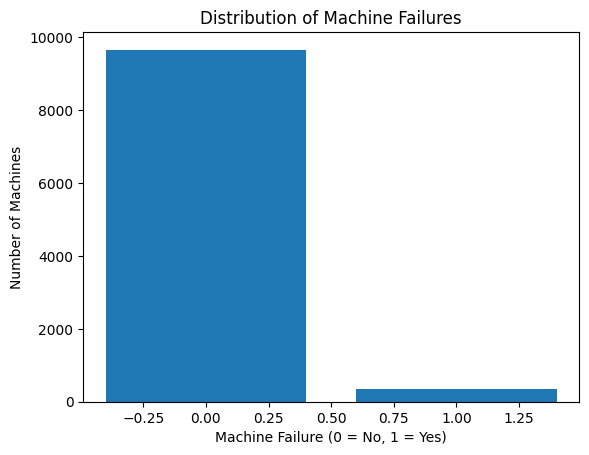

In [7]:
#To Check the machine Faiure count. 
import matplotlib.pyplot as plt
failure_counts = df["Machine failure"].value_counts()

plt.bar(failure_counts.index, failure_counts.values)

plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Number of Machines")
plt.title("Distribution of Machine Failures")

plt.show()

Observation: Machine failures are rare in this dataset. Out of 10,000 observations, only 339 represent machine failure, indicating a class imbalance problem.

## **4. Exploratory Visual Analysis**

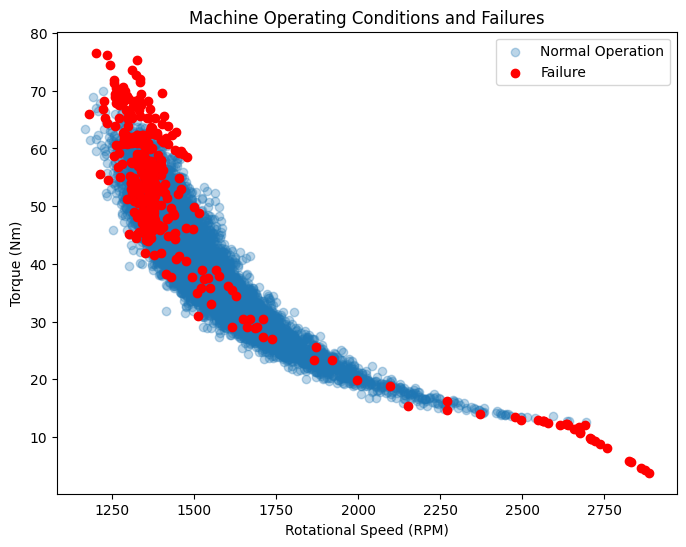

In [8]:
failed = df[df["Machine failure"] == 1]
normal = df[df["Machine failure"] == 0]

plt.figure(figsize=(8,6))

plt.scatter(normal["Rotational speed [rpm]"],
            normal["Torque [Nm]"],
            alpha=0.3,
            label="Normal Operation")

plt.scatter(failed["Rotational speed [rpm]"],
            failed["Torque [Nm]"],
            color="red",
            label="Failure")

plt.xlabel("Rotational Speed (RPM)")
plt.ylabel("Torque (Nm)")
plt.title("Machine Operating Conditions and Failures")

plt.legend()

plt.show()

### Observation

The scatter plot shows the operating conditions of machines in terms of rotational speed and torque. Most machines operate within a central region of the plot, representing normal operating conditions. Machine failures appear in several distinct areas, suggesting that certain combinations of speed and torque may increase the likelihood of breakdown events.

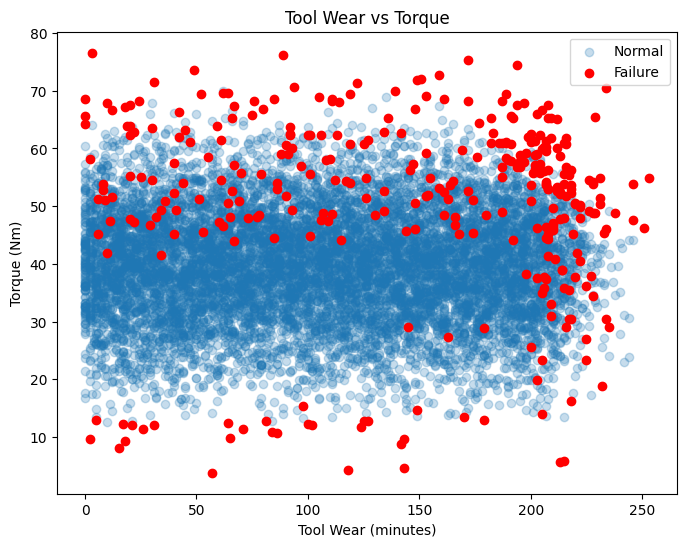

In [9]:
# Tool Wear vs torque 
failed = df[df["Machine failure"] == 1]
normal = df[df["Machine failure"] == 0]

plt.figure(figsize=(8,6))

plt.scatter(normal["Tool wear [min]"],
            normal["Torque [Nm]"],
            alpha=0.25,
            label="Normal")

plt.scatter(failed["Tool wear [min]"],
            failed["Torque [Nm]"],
            color="red",
            label="Failure")

plt.xlabel("Tool Wear (minutes)")
plt.ylabel("Torque (Nm)")
plt.title("Tool Wear vs Torque")

plt.legend()

plt.show()

### **Observation**
The scatter plot compares tool wear and torque for both normal and failed machines. Failures occur across the full range of tool wear values, indicating that tool wear alone is not sufficient to explain machine breakdowns. However, failures appear more frequently at higher torque levels, suggesting that increased mechanical load may contribute to failure events. Additionally, machines experiencing both prolonged tool wear and elevated torque show a higher concentration of failures, indicating that the interaction between wear and mechanical stress may increase the likelihood of machine breakdown.

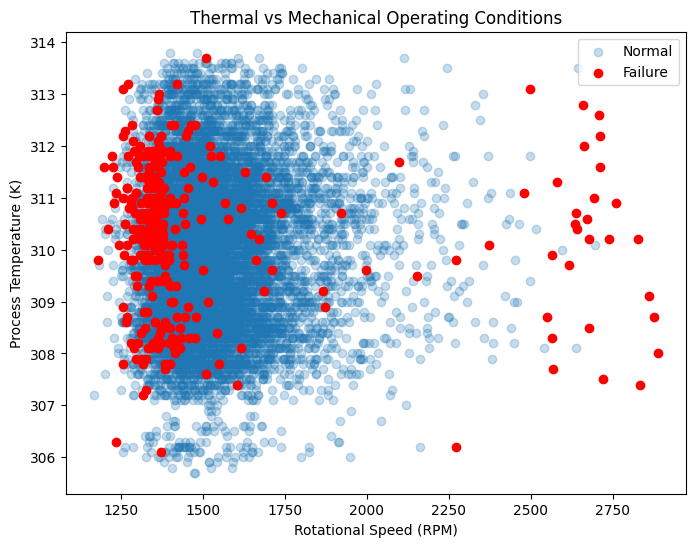

In [10]:
#Thermal VS Mechanical Operating conditions. 
failed = df[df["Machine failure"] == 1]
normal = df[df["Machine failure"] == 0]

plt.figure(figsize=(8,6))

plt.scatter(normal["Rotational speed [rpm]"],
            normal["Process temperature [K]"],
            alpha=0.25,
            label="Normal")

plt.scatter(failed["Rotational speed [rpm]"],
            failed["Process temperature [K]"],
            color="red",
            label="Failure")

plt.xlabel("Rotational Speed (RPM)")
plt.ylabel("Process Temperature (K)")
plt.title("Thermal vs Mechanical Operating Conditions")

plt.legend()

plt.show()

### Observation 
The relationship between lower rotational speed and increased failure frequency may be related to higher torque loads applied during slower machine operation.

In [11]:
# Failure Type Distribution
failure_types = df[["TWF","HDF","PWF","OSF","RNF"]].sum()

failure_types


TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

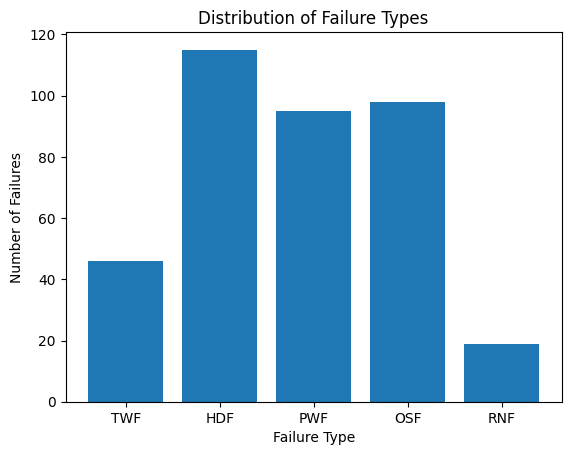

In [12]:
plt.bar(failure_types.index, failure_types.values)

plt.xlabel("Failure Type")
plt.ylabel("Number of Failures")
plt.title("Distribution of Failure Types")

plt.show()

## **6. Outlier Detection**

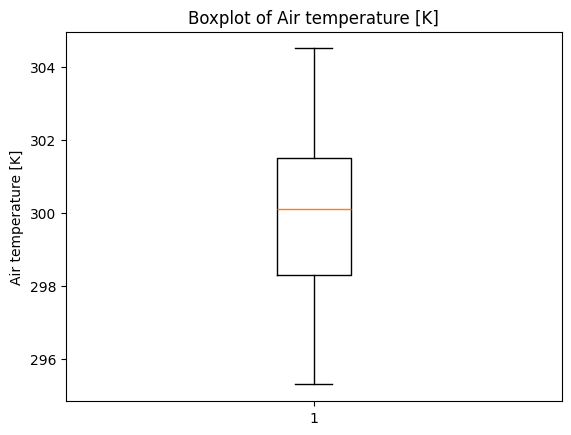

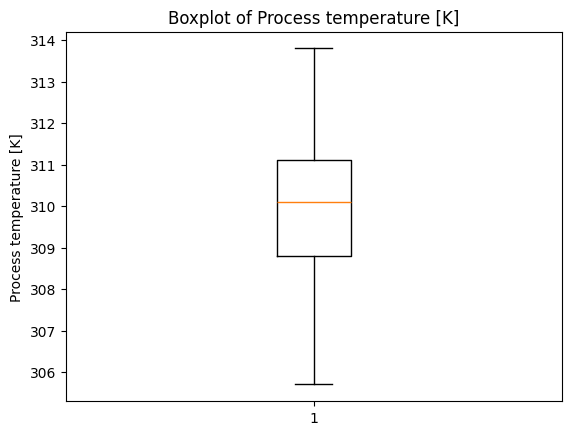

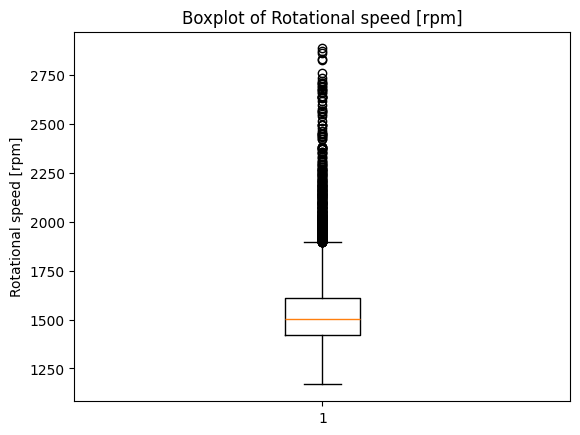

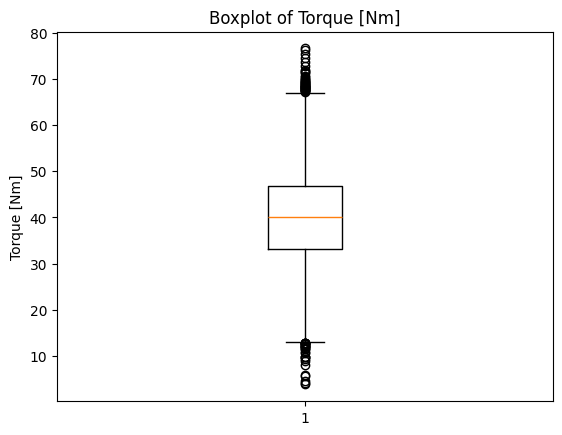

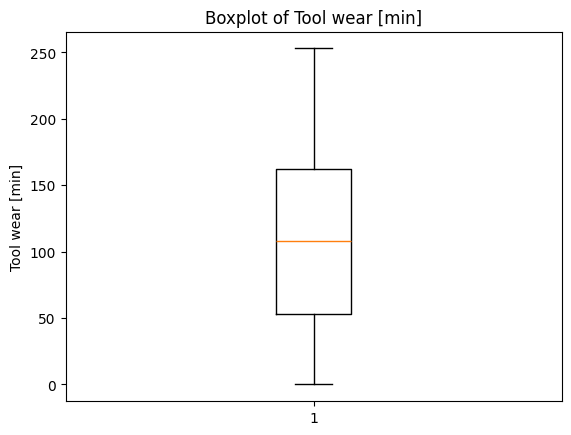

In [13]:
numeric_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for col in numeric_columns:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

### **Outlier Detection Summary**
- Boxplots were used to inspect potential outliers across key machine operational variables.

- Rotational speed and torque display several outliers, likely representing machines operating under extreme or stressed conditions. These values are likely meaningful observations rather than measurement errors and will therefore be retained.

- Air temperature and process temperature exhibit tight distributions without significant outliers, indicating stable operating conditions.

- Tool wear shows a wide but expected range corresponding to progressive equipment wear over time.

## **7. Correlation Analysis** 

In [14]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702,-0.022892,0.009154,-0.022215,-0.023557,-0.000990,-0.005954
Air temperature [K],0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279
Rotational speed [rpm],-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088
Torque [Nm],0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136
Tool wear [min],-0.010702,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326
Machine failure,-0.022892,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.009154,0.009955,0.007315,0.010389,-0.014662,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,-0.022215,0.137831,0.056933,-0.121241,0.142610,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,-0.023557,0.003470,-0.003355,0.123018,0.083781,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273


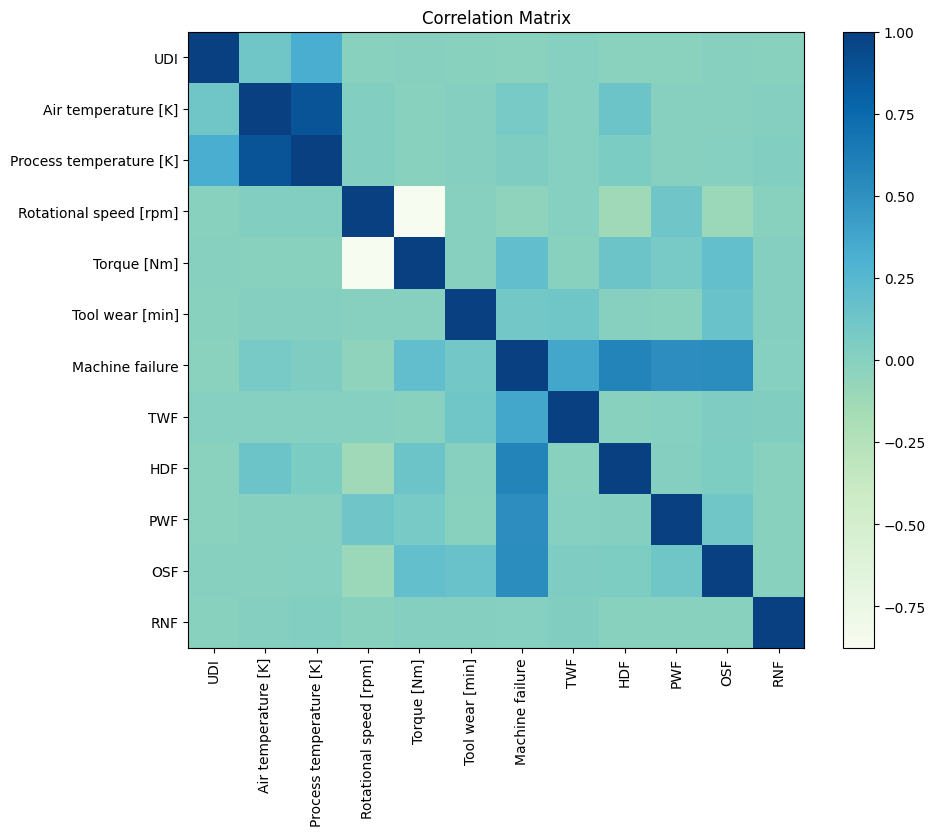

In [15]:
plt.figure(figsize=(10,8))

plt.imshow(corr_matrix, cmap = "GnBu" , interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")

plt.show()

### **Correlation Analysis Observations**

The correlation matrix highlights several important relationships between machine operational variables.
Air temperature and process temperature exhibit strong positive correlation, indicating that machine operating temperature is strongly influenced by environmental conditions.
Rotational speed and torque show a clear negative correlation, reflecting the mechanical relationship between these variables in rotating systems where higher speeds are associated with lower torque loads.
Machine failure shows strong correlations with the specific failure mechanism indicators (TWF, HDF, PWF, OSF), which is expected because machine failure occurs when any of these failure events are triggered.
Tool wear shows moderate correlation with machine failure, suggesting that increased tool usage may contribute to breakdown events, although it is not the sole determining factor.

## **8. Feature Engineering**

In [16]:
df["Mechanical power"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"]

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Mechanical power
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,66382.8
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,65190.4
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,74001.2
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,56603.5
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,56320.0


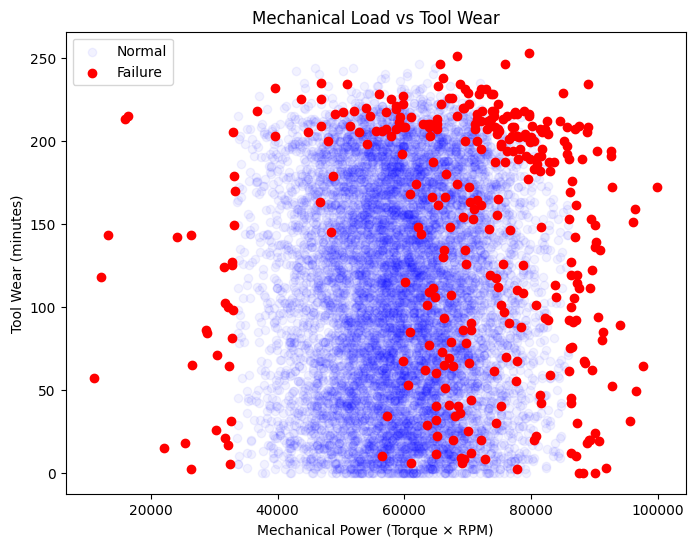

In [18]:
# Visualize Mechanical Power vs Failure
plt.figure(figsize=(8,6))

plt.scatter(normal["Mechanical power"],
            normal["Tool wear [min]"],
            alpha=0.05,
            color="blue",
            label="Normal")

plt.scatter(failed["Mechanical power"],
            failed["Tool wear [min]"],
            color="red",
            label="Failure")

plt.xlabel("Mechanical Power (Torque × RPM)")
plt.ylabel("Tool Wear (minutes)")
plt.title("Mechanical Load vs Tool Wear")

plt.legend()

plt.show()

## **Random Forest Feature Importance**

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

feature_importance

Rotational speed [rpm]     0.175511
Torque [Nm]                0.123958
HDF                        0.122356
Mechanical power           0.119686
PWF                        0.107771
TWF                        0.106062
Tool wear [min]            0.094041
OSF                        0.080291
Air temperature [K]        0.037784
Process temperature [K]    0.022435
Type_L                     0.004599
Type_M                     0.003057
Type_H                     0.001968
RNF                        0.000481
dtype: float64

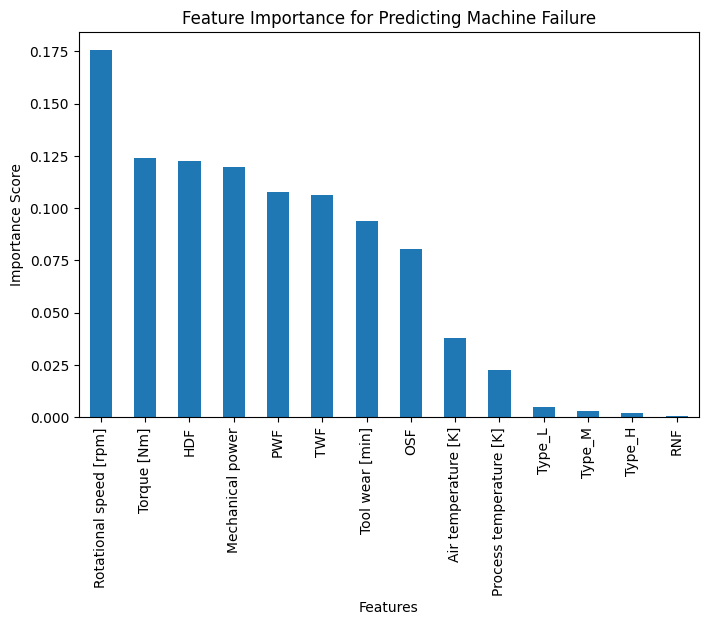

In [40]:
plt.figure(figsize=(8,5))

feature_importance.plot(kind="bar")

plt.title("Feature Importance for Predicting Machine Failure")
plt.ylabel("Importance Score")
plt.xlabel("Features")

plt.show()

## **Preparing Data for Machine Learning**

#### After completing exploratory data analysis, the dataset must be prepared for predictive modeling. This includes encoding categorical variables, removing data leakage variables, and splitting the dataset into training and testing sets.

In [19]:
df = pd.get_dummies(df, columns=["Type"])

df.head()

,UDI,Product ID,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Mechanical power,Type_H,Type_L,Type_M
0,1,M14860,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,66382.8,False,False,True
1,2,L47181,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,65190.4,False,True,False
2,3,L47182,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,74001.2,False,True,False
3,4,L47183,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,56603.5,False,True,False
4,5,L47184,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,56320.0,False,True,False


In [20]:
df = df.drop(columns=["UDI","Product ID"])

In [21]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

C:\Users\Renuka\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [28]:
y_pred = model.predict(X_test) #Makeing a predictor 

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.999

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000


Confusion Matrix:

[[1939    0]
 [   2   59]]


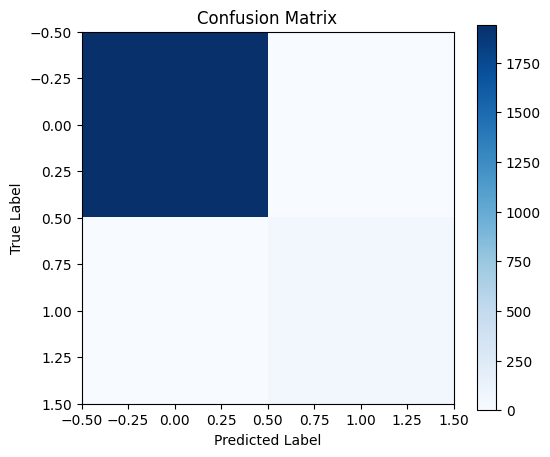

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

## Model Interpretation
The logistic regression model achieved an accuracy of 99.9% in predicting machine failures. The confusion matrix shows that the model correctly classified 1939 normal machines and detected 59 out of 61 failure cases. Only 2 failures were missed. Because machine failure detection is more critical than normal classification, recall for the failure class is an important metric. The model achieved a recall of 0.97 for failure detection, indicating strong predictive capability. These results suggest that operational variables such as tool wear, rotational speed, torque, and mechanical load provide strong signals for predicting machine breakdown events.